In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
assets = ['AAPL', 'MSFT', 'AMZN', 'KO', 'JPM']

prices = yf.download(
    assets,
    start='2021-01-01',
    end='2026-01-01',
    auto_adjust=True
)

prices.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN         JPM         KO        MSFT   
Date                                                                    
2021-01-04  125.632515  159.331497  108.459442  44.527077  207.565399   
2021-01-05  127.185776  160.925507  109.049591  44.037586  207.765579   
2021-01-06  122.904533  156.919006  114.170113  42.636627  202.378403   
2021-01-07  127.098396  158.108002  117.919357  42.164009  208.137497   
2021-01-08  128.195419  159.134995  118.049538  43.109230  209.405594   

Price             High                                                 ...  \
Ticker            AAPL        AMZN         JPM         KO        MSFT  ...   
Date                                                                   ...   
2021-01-04  129.709914  163.600006  110.174180  46.105275  212.628433  ...   
2021-01-05  127.894478  161.169006  109.613717  44.408925  208.356753  ...   
2021-01-06  127.224642  159.875504  115.228932  43.902560  206.421209  ...   
2021-01-07  127.787678  160.427002  119.932854  42.417195  209.138665  ...   
2021-01-08  128.758491  159.531998  118.335941  43.151427  210.320951  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN         JPM         KO        MSFT   
Date                                                                    
2021-01-04  129.622544  163.500000  109.863975  45.801451  212.180291   
2021-01-05  125.127664  158.300507  108.476785  44.164181  207.155346   
2021-01-06  123.991843  157.324005  112.720748  43.860363  202.302122   
2021-01-07  124.613126  157.850006  117.763145  42.273724  204.085161   
2021-01-08  128.564317  159.000000  118.006141  42.223075  208.509310   

Price          Volume                                          
Ticker           AAPL      AMZN       JPM        KO      MSFT  
Date                                                           
2021-01-04  143301900  88228000  16819900  25611100  37130100  
2021-01-05   97664900  53110000  13731200  20323800  23823000  
2021-01-06  155088000  87896000  24909100  38724500  35930700  
2021-01-07  109578200  70290000  21940400  53225700  27694500  
2021-01-08  105158200  70754000  12035100  29674000  22956200  

[5 rows x 25 columns]

In [3]:
returns = prices['Close'].pct_change()
returns = returns.dropna()
returns.head()

Ticker,AAPL,AMZN,JPM,KO,MSFT
Date,,,,,
2021-01-05,0.012364,0.010004,0.005441,-0.010993,0.000964
2021-01-06,-0.033661,-0.024897,0.046956,-0.031813,-0.025929
2021-01-07,0.034123,0.007577,0.032839,-0.011085,0.028457
2021-01-08,0.008631,0.006496,0.001104,0.022418,0.006093
2021-01-11,-0.023249,-0.021519,0.014924,-0.017228,-0.009698


In [4]:
mean_daily_returns = returns.mean()
mean_daily_returns

Ticker
AAPL    0.000767
AMZN    0.000540
JPM     0.000970
KO      0.000394
MSFT    0.000800
dtype: float64

In [5]:
annual_returns = mean_daily_returns * 252
annual_returns

Ticker
AAPL    0.193226
AMZN    0.136019
JPM     0.244470
KO      0.099352
MSFT    0.201725
dtype: float64

In [6]:
daily_volatility = returns.std()

daily_volatility

Ticker
AAPL    0.017552
AMZN    0.022115
JPM     0.015292
KO      0.009975
MSFT    0.016198
dtype: float64

In [7]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

Ticker
AAPL    0.278626
AMZN    0.351060
JPM     0.242747
KO      0.158349
MSFT    0.257143
dtype: float64

In [8]:
covariance = returns.cov()
correlation = returns.corr()

print("Covariance Matrix:")
display(covariance)

print("Correlation Matrix:")
display(correlation)

Covariance Matrix:


Ticker,AAPL,AMZN,JPM,KO,MSFT
Ticker,,,,,
AAPL,0.000308,0.000218,0.000093,0.000047,0.000180
AMZN,0.000218,0.000489,0.000116,0.000024,0.000235
JPM,0.000093,0.000116,0.000234,0.000035,0.000077
KO,0.000047,0.000024,0.000035,0.000100,0.000033
MSFT,0.000180,0.000235,0.000077,0.000033,0.000262


Correlation Matrix:


Ticker,AAPL,AMZN,JPM,KO,MSFT
Ticker,,,,,
AAPL,1.000000,0.561306,0.345422,0.271277,0.633958
AMZN,0.561306,1.000000,0.342755,0.108686,0.654728
JPM,0.345422,0.342755,1.000000,0.229096,0.311269
KO,0.271277,0.108686,0.229096,1.000000,0.206732
MSFT,0.633958,0.654728,0.311269,0.206732,1.000000


In [9]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

print("Total weight:", weights.sum())

Total weight: 1.0


In [10]:
portfolio_return = np.dot(weights, annual_returns)

annual_covariance = returns.cov() * 252

portfolio_variance = weights.T @ annual_covariance @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Portfolio annual return: {portfolio_return:.2%}")
print(f"Portfolio annual volatility: {portfolio_volatility:.2%}")

Portfolio annual return: 17.50%
Portfolio annual volatility: 18.81%


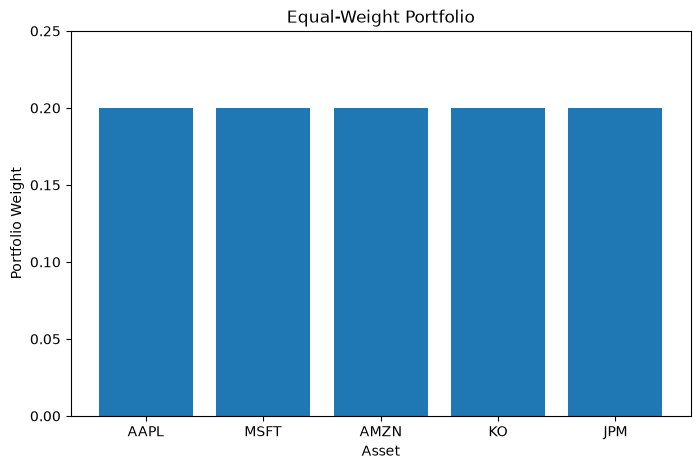

In [11]:
labels = assets

plt.figure(figsize=(8, 5))
plt.bar(labels, weights)

plt.title("Equal-Weight Portfolio")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.ylim(0, 0.25)

plt.show()

In [12]:
from scipy.optimize import minimize

# Expected returns and covariance matrix
mu = annual_returns[assets].to_numpy()
cov = (returns[assets].cov() * 252).to_numpy()

# Portfolio functions
def portfolio_return(weights):
    return weights @ mu

def portfolio_volatility(weights):
    return np.sqrt(weights @ cov @ weights)

# Start with equal weights
initial_weights = np.array([0.20] * 5)

# All weights must add up to 1
constraints = ({
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
})

# No short selling: each weight must be between 0% and 100%
bounds = tuple((0, 1) for _ in assets)

# Minimise portfolio volatility
result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

print("Optimal weights:")
for asset, weight in zip(assets, optimal_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {optimal_weights.sum():.2%}")
print(f"Portfolio return: {portfolio_return(optimal_weights):.2%}")
print(f"Portfolio volatility: {portfolio_volatility(optimal_weights):.2%}")

Optimal weights:
AAPL: 0.27%
MSFT: 14.49%
AMZN: 1.31%
KO: 66.32%
JPM: 17.60%

Total weight: 100.00%
Portfolio return: 14.05%
Portfolio volatility: 13.96%


In [13]:
def negative_return(weights):
    return -portfolio_return(weights)

result_max_return = minimize(
    negative_return,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_return_weights = result_max_return.x

print("Maximum-return portfolio:")

for asset, weight in zip(assets, max_return_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {max_return_weights.sum():.2%}")
print(f"Portfolio return: {portfolio_return(max_return_weights):.2%}")
print(f"Portfolio volatility: {portfolio_volatility(max_return_weights):.2%}")

Maximum-return portfolio:
AAPL: 0.00%
MSFT: 0.00%
AMZN: 0.00%
KO: 0.00%
JPM: 100.00%

Total weight: 100.00%
Portfolio return: 24.45%
Portfolio volatility: 24.27%


In [14]:
annual_returns[assets]

Ticker
AAPL    0.193226
MSFT    0.201725
AMZN    0.136019
KO      0.099352
JPM     0.244470
dtype: float64

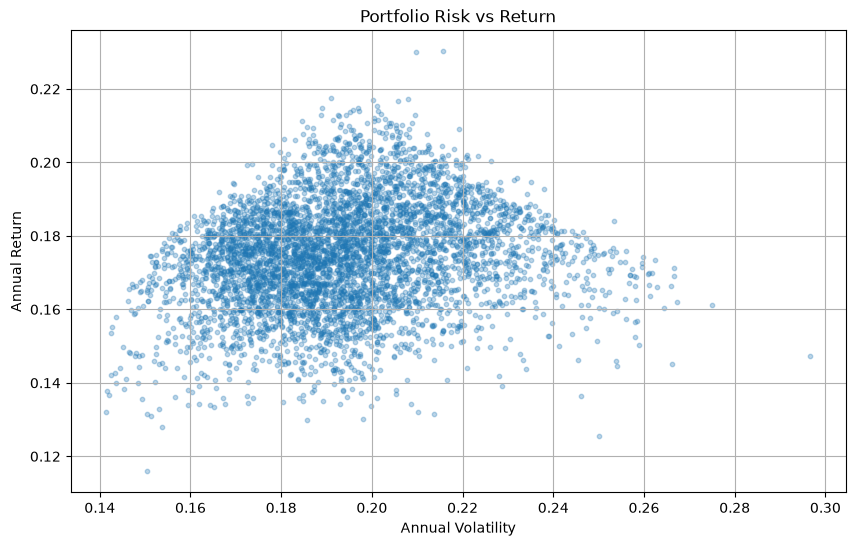

In [15]:
num_portfolios = 5000

portfolio_returns = []
portfolio_volatilities = []
portfolio_weights = []

for _ in range(num_portfolios):
    random_weights = np.random.random(len(assets))
    random_weights /= np.sum(random_weights)

    ret = portfolio_return(random_weights)
    vol = portfolio_volatility(random_weights)

    portfolio_returns.append(ret)
    portfolio_volatilities.append(vol)
    portfolio_weights.append(random_weights)

plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.3,
    s=10
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Portfolio Risk vs Return")
plt.grid(True)

plt.show()

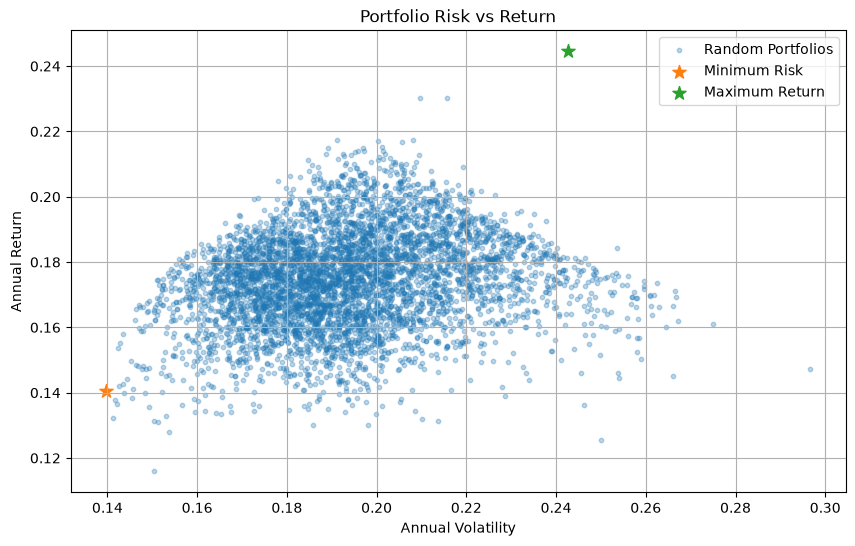

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.3,
    s=10,
    label="Random Portfolios"
)

# Minimum-risk portfolio
min_risk = portfolio_volatility(optimal_weights)
min_risk_return = portfolio_return(optimal_weights)

plt.scatter(
    min_risk,
    min_risk_return,
    s=100,
    marker="*",
    label="Minimum Risk"
)

# Maximum-return portfolio
max_return = portfolio_return(max_return_weights)
max_return_vol = portfolio_volatility(max_return_weights)

plt.scatter(
    max_return_vol,
    max_return,
    s=100,
    marker="*",
    label="Maximum Return"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Portfolio Risk vs Return")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
target_returns = np.linspace(
    portfolio_return(optimal_weights),
    portfolio_return(max_return_weights),
    50
)

efficient_volatilities = []

for target in target_returns:

    constraints_frontier = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights, target=target:
                portfolio_return(weights) - target
        }
    )

    result_frontier = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_frontier
    )

    efficient_volatilities.append(
        portfolio_volatility(result_frontier.x)
    )

print("Efficient frontier calculated!")
print(f"Number of portfolios: {len(target_returns)}")

Efficient frontier calculated!
Number of portfolios: 50


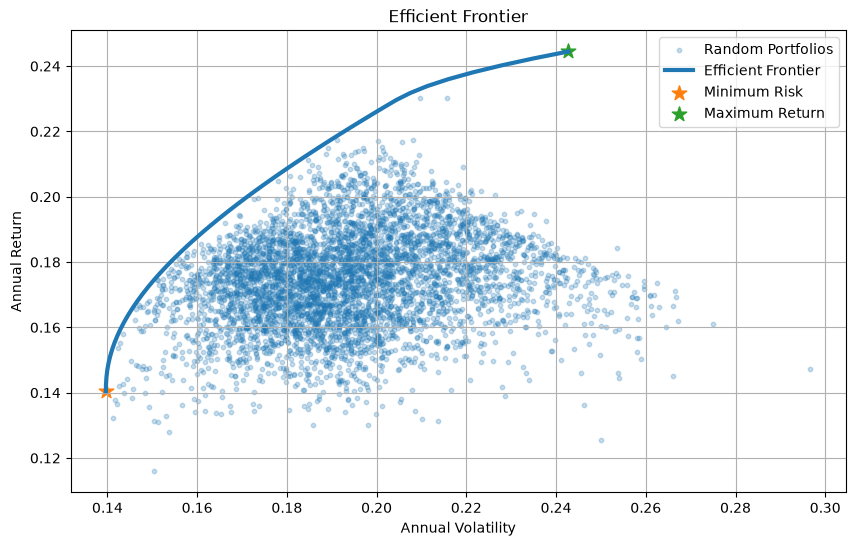

In [19]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.25,
    s=10,
    label="Random Portfolios"
)

# Efficient frontier
plt.plot(
    efficient_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum-risk portfolio
plt.scatter(
    min_risk,
    min_risk_return,
    s=120,
    marker="*",
    label="Minimum Risk"
)

# Maximum-return portfolio
plt.scatter(
    max_return_vol,
    max_return,
    s=120,
    marker="*",
    label="Maximum Return"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)
plt.savefig("../results/efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
risk_free_rate = 0.04

def negative_sharpe_ratio(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)

    sharpe = (ret - risk_free_rate) / vol

    return -sharpe

result_sharpe = minimize(
    negative_sharpe_ratio,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

sharpe_weights = result_sharpe.x

sharpe_return = portfolio_return(sharpe_weights)
sharpe_volatility = portfolio_volatility(sharpe_weights)
sharpe_ratio = (sharpe_return - risk_free_rate) / sharpe_volatility

print("Maximum Sharpe Ratio Portfolio:")

for asset, weight in zip(assets, sharpe_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {sharpe_weights.sum():.2%}")
print(f"Portfolio return: {sharpe_return:.2%}")
print(f"Portfolio volatility: {sharpe_volatility:.2%}")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")

Maximum Sharpe Ratio Portfolio:
AAPL: 3.60%
MSFT: 26.59%
AMZN: 0.00%
KO: 15.75%
JPM: 54.06%

Total weight: 100.00%
Portfolio return: 20.84%
Portfolio volatility: 17.98%
Sharpe ratio: 0.94


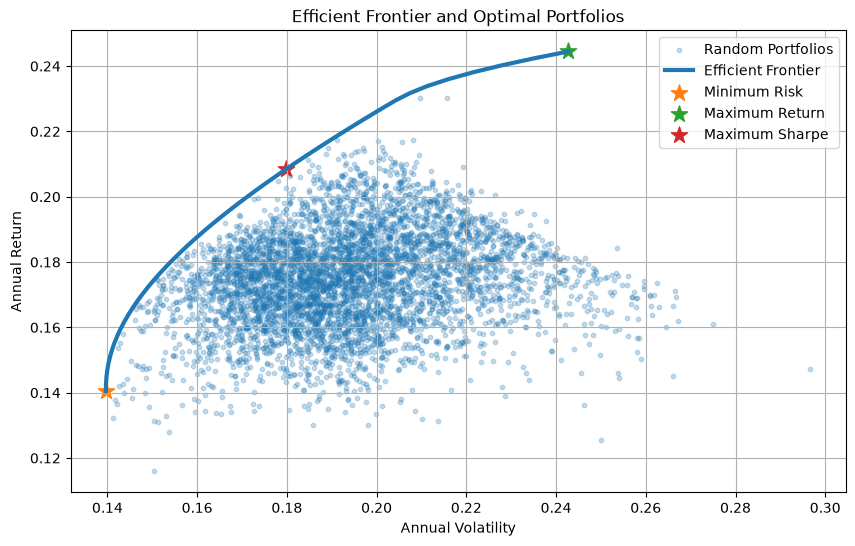

In [21]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.25,
    s=10,
    label="Random Portfolios"
)

# Efficient frontier
plt.plot(
    efficient_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum-risk portfolio
plt.scatter(min_risk, min_risk_return, s=150, marker="*", label="Minimum Risk")

# Maximum-return portfolio
plt.scatter(max_return_vol, max_return, s=150, marker="*", label="Maximum Return")

# Maximum-Sharpe portfolio
plt.scatter(sharpe_volatility, sharpe_return, s=150, marker="*", label="Maximum Sharpe")

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier and Optimal Portfolios")
plt.legend()
plt.grid(True)

plt.savefig("../results/efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Risk",
        "Maximum Return",
        "Maximum Sharpe"
    ],
    "Expected Return": [
        portfolio_return(initial_weights),
        min_risk_return,
        max_return,
        sharpe_return
    ],
    "Volatility": [
        portfolio_volatility(initial_weights),
        min_risk,
        max_return_vol,
        sharpe_volatility
    ],
    "Sharpe Ratio": [
        (portfolio_return(initial_weights) - risk_free_rate)
        / portfolio_volatility(initial_weights),

        (min_risk_return - risk_free_rate) / min_risk,

        (max_return - risk_free_rate) / max_return_vol,

        sharpe_ratio
    ]
})

comparison["Expected Return"] = comparison["Expected Return"].map(
    lambda x: f"{x:.2%}"
)

comparison["Volatility"] = comparison["Volatility"].map(
    lambda x: f"{x:.2%}"
)

comparison["Sharpe Ratio"] = comparison["Sharpe Ratio"].map(
    lambda x: f"{x:.2f}"
)

comparison

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Equal Weight,17.50%,18.81%,0.72
1,Minimum Risk,14.05%,13.96%,0.72
2,Maximum Return,24.45%,24.27%,0.84
3,Maximum Sharpe,20.84%,17.98%,0.94


In [23]:
comparison.to_csv("../results/portfolio_comparison.csv", index=False)

weights_df = pd.DataFrame({
    "Asset": assets,
    "Minimum Risk": optimal_weights,
    "Maximum Sharpe": sharpe_weights,
    "Maximum Return": max_return_weights
})

weights_df.to_csv("../results/optimal_weights.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


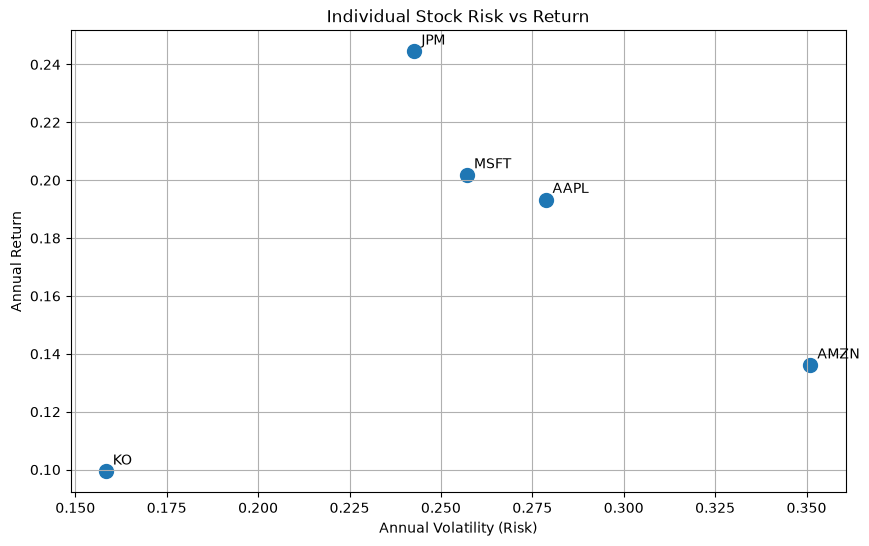

In [24]:
asset_returns = annual_returns[assets]
asset_volatility = returns[assets].std() * np.sqrt(252)

plt.figure(figsize=(10, 6))

plt.scatter(asset_volatility, asset_returns, s=100)

for asset in assets:
    plt.annotate(
        asset,
        (asset_volatility[asset], asset_returns[asset]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Annual Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Individual Stock Risk vs Return")
plt.grid(True)
plt.savefig("../results/individual_stock_risk_return.png", dpi=300, bbox_inches="tight")
plt.show()

### Individual Stock Risk and Return Analysis

The risk-return analysis compares the annualised historical returns and volatility of five stocks: Apple (AAPL), Microsoft (MSFT), Amazon (AMZN), JPMorgan Chase (JPM), and Coca-Cola (KO).

JPM recorded the highest annualised historical return at approximately 27.68%, although its return was accompanied by volatility. KO had the lowest annualised volatility, at approximately 16%, but also recorded the lowest annualised return at approximately 10.39%.

AMZN showed the highest volatility among the five stocks, at approximately 35%, while its historical annualised return was approximately 11.73%. AAPL and MSFT delivered similar historical returns of approximately 19.50% and 19.16%, respectively.

These findings illustrate the relationship between historical return and risk. However, individual stock performance alone does not determine the best portfolio. Correlations between assets and diversification also affect overall portfolio risk.

*Note: Historical returns and volatility are based on the selected data period and do not guarantee future performance.*


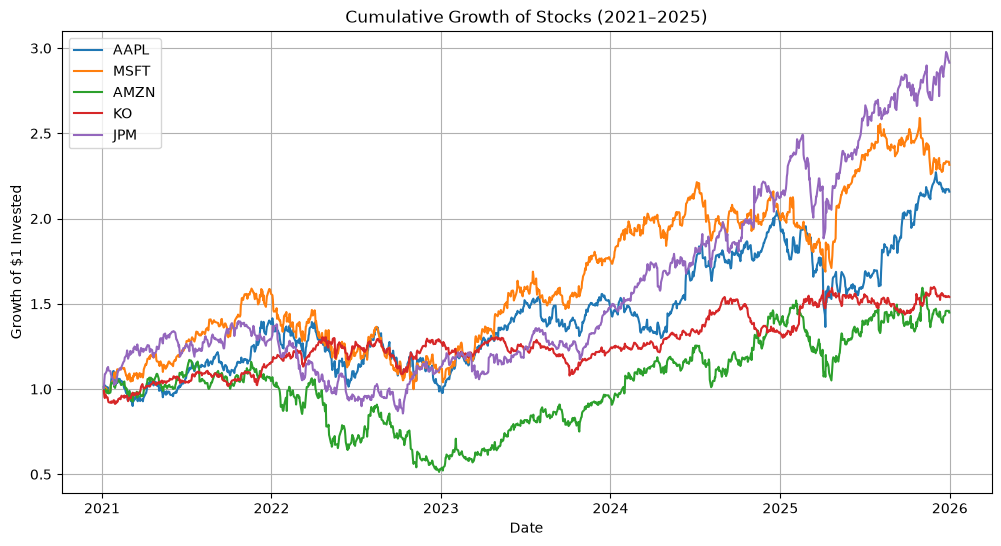

In [25]:
# Calculate cumulative growth from daily returns
cumulative_returns = (1 + returns[assets]).cumprod()

# Plot cumulative growth
plt.figure(figsize=(12, 6))

for asset in assets:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[asset],
        label=asset
    )

plt.title("Cumulative Growth of Stocks (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True)
plt.savefig("../results/cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Download S&P 500 ETF data for the same period
benchmark_prices = yf.download(
    "SPY",
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

# Handle different yfinance column formats
if isinstance(benchmark_prices.columns, pd.MultiIndex):
    spy_prices = benchmark_prices["Close"].iloc[:, 0]
else:
    spy_prices = benchmark_prices["Close"]

# Calculate daily benchmark returns
spy_returns = spy_prices.pct_change().dropna()

# Calculate equal-weight portfolio daily returns
equal_weight_returns = returns[assets].dot(initial_weights)

# Align both series to the same dates
aligned_returns = pd.concat(
    [
        equal_weight_returns.rename("Equal-Weight Portfolio"),
        spy_returns.rename("S&P 500 Benchmark (SPY)")
    ],
    axis=1
).dropna()

# Compare annualised return and volatility
benchmark_comparison = pd.DataFrame({
    "Annual Return": aligned_returns.mean() * 252,
    "Annual Volatility": aligned_returns.std() * np.sqrt(252)
})

print("Portfolio vs Market Benchmark")
display(benchmark_comparison.style.format("{:.2%}"))

Portfolio vs Market Benchmark


,Annual Return,Annual Volatility
Equal-Weight Portfolio,17.50%,18.81%
S&P 500 Benchmark (SPY),15.20%,17.11%


In [27]:
# Split the data into training and testing periods
split_date = "2024-01-01"

train_asset_returns = returns.loc[
    returns.index < split_date, assets
].dropna()

test_asset_returns = returns.loc[
    returns.index >= split_date, assets
].dropna()

# Estimate expected returns and covariance using training data only
train_mu = train_asset_returns.mean().to_numpy() * 252
train_cov = train_asset_returns.cov().to_numpy() * 252

# Find the maximum-Sharpe portfolio using training data
def negative_train_sharpe(weights):
    ret = weights @ train_mu
    vol = np.sqrt(weights @ train_cov @ weights)

    return -(ret - risk_free_rate) / vol

result_oos = minimize(
    negative_train_sharpe,
    np.repeat(1 / len(assets), len(assets)),
    method="SLSQP",
    bounds=tuple((0, 1) for _ in assets),
    constraints={
        "type": "eq",
        "fun": lambda weights: weights.sum() - 1
    }
)

if not result_oos.success:
    raise RuntimeError(result_oos.message)

optimized_oos_weights = result_oos.x

# Evaluate on the unseen testing period
equal_test_returns = test_asset_returns.dot(
    np.repeat(1 / len(assets), len(assets))
).rename("Equal-Weight Portfolio")

optimized_test_returns = test_asset_returns.dot(
    optimized_oos_weights
).rename("Training-Optimized Portfolio")

benchmark_test_returns = spy_returns.rename(
    "S&P 500 Benchmark (SPY)"
)

test_comparison = pd.concat(
    [
        equal_test_returns,
        optimized_test_returns,
        benchmark_test_returns
    ],
    axis=1
).dropna()

# Calculate performance metrics on the testing period
test_annual_return = test_comparison.mean() * 252
test_annual_volatility = test_comparison.std() * np.sqrt(252)
test_sharpe = (
    test_annual_return - risk_free_rate
) / test_annual_volatility

test_summary = pd.DataFrame({
    "Annual Return": test_annual_return,
    "Annual Volatility": test_annual_volatility,
    "Sharpe Ratio": test_sharpe
})

display(test_summary.style.format({
    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
}))

print("Optimised weights learned from 2021–2023 data:")
for asset, weight in zip(assets, optimized_oos_weights):
    print(f"{asset}: {weight:.2%}")

/tmp/ipykernel_39151/2558840488.py:52: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  test_comparison = pd.concat(


,Annual Return,Annual Volatility,Sharpe Ratio
Equal-Weight Portfolio,22.67%,16.42%,1.14
Training-Optimized Portfolio,23.84%,18.93%,1.05
S&P 500 Benchmark (SPY),20.68%,16.37%,1.02


Optimised weights learned from 2021–2023 data:
AAPL: 0.00%
MSFT: 62.54%
AMZN: 0.00%
KO: 0.00%
JPM: 37.46%


In [28]:
# Save out-of-sample performance comparison
test_summary.to_csv(
    "../results/out_of_sample_comparison.csv",
    index_label="Portfolio"
)

# Save the optimised weights learned from 2021–2023
validation_weights = pd.DataFrame({
    "Asset": assets,
    "Training-Optimised Weight": optimized_oos_weights
})

validation_weights.to_csv(
    "../results/out_of_sample_weights.csv",
    index=False
)

print("Out-of-sample results saved successfully!")

Out-of-sample results saved successfully!


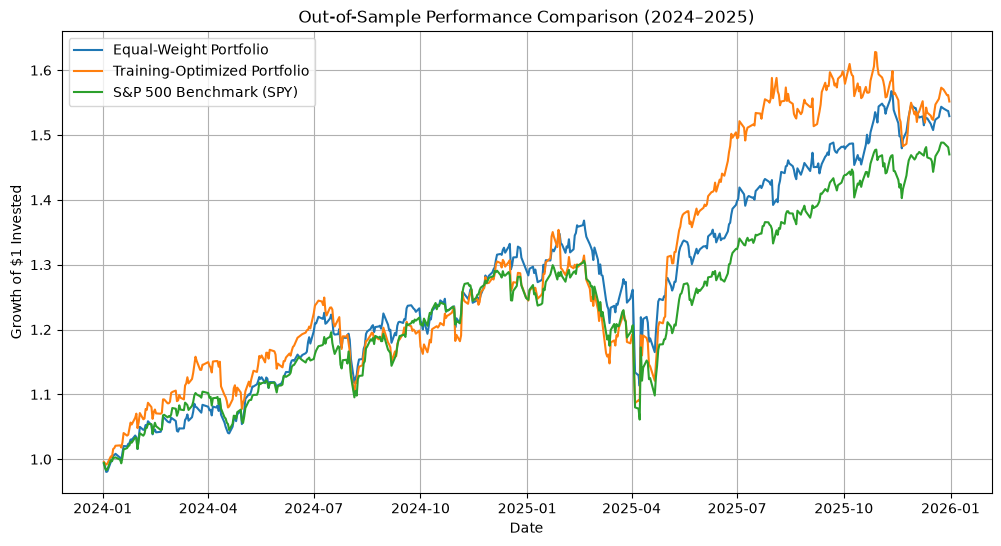

In [29]:
# Calculate cumulative growth during the testing period
test_growth = (1 + test_comparison).cumprod()

plt.figure(figsize=(12, 6))

for column in test_growth.columns:
    plt.plot(
        test_growth.index,
        test_growth[column],
        label=column
    )

plt.title("Out-of-Sample Performance Comparison (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/out_of_sample_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Rolling-window validation: train on 2 years, test on the next year
def max_sharpe_weights(train_returns):
    mu_t = train_returns.mean().to_numpy() * 252
    cov_t = train_returns.cov().to_numpy() * 252
    n = train_returns.shape[1]

    def neg_sharpe(w):
        return -(w @ mu_t - risk_free_rate) / np.sqrt(w @ cov_t @ w)

    res = minimize(
        neg_sharpe,
        np.repeat(1 / n, n),
        method="SLSQP",
        bounds=tuple((0, 1) for _ in range(n)),
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
    )
    if not res.success:
        raise RuntimeError(res.message)
    return res.x

windows = [(2021, 2022, 2023), (2022, 2023, 2024), (2023, 2024, 2025)]
equal_w = np.repeat(1 / len(assets), len(assets))

rows = []
for train_start, train_end, test_year in windows:
    train = returns.loc[f"{train_start}-01-01":f"{train_end}-12-31", assets]
    test = returns.loc[f"{test_year}-01-01":f"{test_year}-12-31", assets]

    w = max_sharpe_weights(train)

    perf = pd.concat(
        [
            test.dot(equal_w).rename("Equal-Weight"),
            test.dot(w).rename("Optimised"),
            spy_returns.rename("SPY")
        ],
        axis=1,
        sort=True
    ).dropna()

    ann_ret = perf.mean() * 252
    ann_vol = perf.std() * np.sqrt(252)
    sharpe = (ann_ret - risk_free_rate) / ann_vol

    print(f"Train {train_start}-{train_end} -> Test {test_year}")
    print("  Weights:", {a: f"{x:.1%}" for a, x in zip(assets, w)})

    for name in perf.columns:
        rows.append({
            "Test Year": test_year,
            "Portfolio": name,
            "Annual Return": ann_ret[name],
            "Annual Volatility": ann_vol[name],
            "Sharpe Ratio": sharpe[name]
        })

rolling_results = pd.DataFrame(rows)

display(
    rolling_results.style.format({
        "Annual Return": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}"
    })
)

# Average Sharpe ratio across the three test years
print("\nAverage Sharpe ratio across windows:")
print(rolling_results.groupby("Portfolio")["Sharpe Ratio"].mean().round(2))

rolling_results.to_csv("../results/rolling_window_comparison.csv", index=False)

Train 2021-2022 -> Test 2023
  Weights: {'AAPL': '0.0%', 'MSFT': '0.0%', 'AMZN': '0.0%', 'KO': '100.0%', 'JPM': '0.0%'}
Train 2022-2023 -> Test 2024
  Weights: {'AAPL': '0.0%', 'MSFT': '46.7%', 'AMZN': '0.0%', 'KO': '0.0%', 'JPM': '53.3%'}
Train 2023-2024 -> Test 2025
  Weights: {'AAPL': '34.9%', 'MSFT': '0.0%', 'AMZN': '27.3%', 'KO': '0.0%', 'JPM': '37.9%'}


,Test Year,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio
0,2023,Equal-Weight,36.46%,15.13%,2.15
1,2023,Optimised,-3.67%,13.47%,-0.57
2,2023,SPY,24.30%,13.08%,1.55
3,2024,Equal-Weight,26.59%,13.49%,1.67
4,2024,Optimised,27.63%,16.75%,1.41
5,2024,SPY,23.02%,12.57%,1.51
6,2025,Equal-Weight,18.72%,18.95%,0.78
7,2025,Optimised,21.12%,25.09%,0.68
8,2025,SPY,18.32%,19.49%,0.73



Average Sharpe ratio across windows:
Portfolio
Equal-Weight    1.53
Optimised       0.51
SPY             1.27
Name: Sharpe Ratio, dtype: float64
